In [1]:
# !pip install roboflow

In [ ]:

# from roboflow import Roboflow
# rf = Roboflow(api_key="")
# project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
# version = project.version(13)
# dataset = version.download("darknet")

In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [5]:
import torch
print(torch.version.cuda)  # should be 13.x
print(torch.cuda.is_available())  # should be True
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(torch.cuda.current_device()))

11.3
True
0
Tesla P100-PCIE-16GB


/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# import os

# dataset_path = "/app/notebooks/License-Plate-Recognition-13"
# for split in ["train", "valid"]:
#     label_dir = os.path.join(dataset_path, split)
#     for fname in os.listdir(label_dir):
#         if not fname.endswith(".txt"):
#             continue
#         with open(os.path.join(label_dir, fname)) as f:
#             for i, line in enumerate(f):
#                 parts = line.strip().split()
#                 if not parts:
#                     continue
#                 cls = int(parts[0])
#                 if cls >= 3 or cls < 0:
#                     print(f"BAD LABEL in {fname} line {i}: class={cls}")

In [ ]:
from super_gradients.training.datasets import YoloDarknetFormatDetectionDataset

dataset_path = "./License-Plate-Recognition-13"

train_dataset = YoloDarknetFormatDetectionDataset(
    data_dir=dataset_path,
    images_dir="train",
    labels_dir="train",
    classes=["License_Plate"],
    show_all_warnings=True
)

val_dataset = YoloDarknetFormatDetectionDataset(
    data_dir=dataset_path,
    images_dir="valid",
    labels_dir="valid",
    classes=["License_Plate"]
)

The console stream is logged into /root/sg_logs/console.log


[2026-03-06 13:19:45] INFO - crash_tips_setup.py - Crash tips is enabled. You can set your environment variable to CRASH_HANDLER=FALSE to disable it


[WARNING]No module named 'pycocotools'


[2026-03-06 13:19:48] INFO - env_sanity_check.py - Library check is not supported when super_gradients installed through "git+https://github.com/..." command
[2026-03-06 13:19:49] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.
Indexing dataset annotations: 100%|██████████| 98798/98798 [00:16<00:00, 5841.32it/s]
[2026-03-06 13:20:06] INFO - detection_dataset.py - Dataset Initialization in progress. `cache_annotations=True` causes the process to take longer due to full dataset indexing.
Indexing dataset annotations:  84%|████████▍ | 1722/2048 [00:00<00:00, 5814.75it/s]

Indexing dataset annotations: 100%|██████████| 2048/2048 [00:00<00:00, 5729.10it/s]


The dataset was returning each sample's labels as [x1, y1, x2, y2, class], but YOLOX loss expects targets in [batch_idx, class, cx, cy, w, h] format. Three things were wrong:

Class was in the last column — we were accidentally reading x1 as the class, which gave huge values like 305, 268 etc. that were way out of range for F.one_hot(..., num_classes=3), triggering the CUDA assert.
No batch index — the loss needs to know which image each box belongs to since all boxes across the batch are concatenated into one tensor. We prepended i (the loop index) for each sample.
Corner format → center format — the dataset gave [x1, y1, x2, y2] (top-left/bottom-right corners) but YOLOX expects [cx, cy, w, h] (center + dimensions), so we converted them.

In [ ]:
import cv2
from torch.utils.data import DataLoader
from super_gradients.training.utils.collate_fn import DetectionCollateFN
import numpy as np
import torch
def yolox_collate_fn(batch, input_size=640):
    imgs, targets = zip(*batch)

    resized_imgs = []
    padded_targets = []

    for i, (img, t) in enumerate(zip(imgs, targets)):
        img = np.array(img)
        orig_h, orig_w = img.shape[:2]
        img = cv2.resize(img, (input_size, input_size))
        resized_imgs.append(torch.from_numpy(img).permute(2, 0, 1).float())

        t = torch.as_tensor(t, dtype=torch.float32)
        if t.shape[0] > 0:
            # Scale boxes to new size
            sx = input_size / orig_w
            sy = input_size / orig_h
            x1 = t[:, 0] * sx
            y1 = t[:, 1] * sy
            x2 = t[:, 2] * sx
            y2 = t[:, 3] * sy
            cls = t[:, 4:5]

            cx = ((x1 + x2) / 2).unsqueeze(1)
            cy = ((y1 + y2) / 2).unsqueeze(1)
            w  = (x2 - x1).unsqueeze(1)
            h  = (y2 - y1).unsqueeze(1)
            batch_col = torch.full((t.shape[0], 1), i, dtype=torch.float32)
            padded_targets.append(torch.cat([batch_col, cls, cx, cy, w, h], dim=1))

    imgs = torch.stack(resized_imgs, 0)
    targets = torch.cat(padded_targets, 0) if padded_targets else torch.zeros((0, 6))
    return imgs, targets
train_loader = DataLoader(train_dataset, num_workers=4, batch_size=32, shuffle=True, collate_fn=yolox_collate_fn)
val_loader = DataLoader(val_dataset, num_workers=4, batch_size=32, shuffle=False, collate_fn=yolox_collate_fn)

In [9]:
from super_gradients.training import models
from super_gradients.training import Trainer
import torch
from torch.utils.data import DataLoader
from super_gradients.common.object_names import Models

trainer = Trainer(experiment_name="yolon", ckpt_root_dir="./checkpoints")

model = models.get(
    Models.YOLOX_N,
    num_classes=1,
    checkpoint_path="/app/models/yolox_nano.pth",
    strict_load=False
    
)
model.num_classes

/usr/local/lib/python3.8/dist-packages/super_gradients/common/deprecate.py:279: DeprecationWarning: Parameter `arch_params.channels_in` is deprecated since version `3.3.0` and will be removed in version `4.0.0`.
Please update your code to use the `arch_params.in_channels` instead of `arch_params.channels_in`.
  warnings.warn(message, DeprecationWarning)
[2026-03-06 13:20:07] INFO - checkpoint_utils.py - Successfully loaded model weights from /app/models/yolox_nano.pth checkpoint.


1

In [10]:
from super_gradients.training import training_hyperparams
train_params = training_hyperparams.get('coco2017_yolox')
train_params

{'resume': None,
 'run_id': None,
 'resume_path': None,
 'resume_from_remote_sg_logger': False,
 'ckpt_name': 'ckpt_latest.pth',
 'lr_mode': 'CosineLRScheduler',
 'lr_schedule_function': None,
 'lr_warmup_epochs': 5,
 'lr_warmup_steps': 0,
 'lr_cooldown_epochs': 15,
 'warmup_initial_lr': None,
 'step_lr_update_freq': None,
 'cosine_final_lr_ratio': 0.05,
 'warmup_mode': 'LinearEpochLRWarmup',
 'lr_updates': [],
 'pre_prediction_callback': None,
 'optimizer': 'SGD',
 'optimizer_params': {'momentum': 0.9, 'weight_decay': 0.0005, 'nesterov': True},
 'load_opt_params': True,
 'zero_weight_decay_on_bias_and_bn': True,
 'loss': 'YoloXDetectionLoss',
 'criterion_params': {'strides': [8, 16, 32], 'num_classes': 80},
 'ema': True,
 'ema_params': {'decay': 0.9999, 'decay_type': 'exp', 'beta': 15},
 'train_metrics_list': [],
 'valid_metrics_list': [{'DetectionMetrics': {'normalize_targets': True, 'post_prediction_callback': YoloXPostPredictionCallback(), 'num_cls': 80}}],
 'metric_to_watch': 'mAP

In [13]:
train_params['max_epochs'] = 10
train_params['initial_lr'] = 0.001
train_params['cosine_final_lr_ratio'] = 0.05
train_params['lr_warmup_epochs'] = 3
train_params['lr_cooldown_epochs'] = 10
train_params['criterion_params']['num_classes'] = 1
train_params['average_best_models'] = True
train_params['mixed_precision'] = True
train_params['ema'] = True
train_params['sync_bn'] = False

In [ ]:
trainer.train(model=model, training_params=train_params, train_loader=train_loader, valid_loader=val_loader)

[2026-03-06 13:24:10] WARNING - sg_trainer.py - Train dataset size % batch_size != 0 and drop_last=False, this might result in smaller last batch.
[2026-03-06 13:24:10] INFO - sg_trainer.py - Starting a new run with `run_id=RUN_20260306_132410_813259`
[2026-03-06 13:24:10] INFO - sg_trainer.py - Checkpoints directory: ./checkpoints/yolon/RUN_20260306_132410_813259
[2026-03-06 13:24:10] INFO - sg_trainer.py - Using EMA with params {'decay': 0.9999, 'decay_type': 'exp', 'beta': 15}


The console stream is now moved to ./checkpoints/yolon/RUN_20260306_132410_813259/console_Mar06_13_24_10.txt


/usr/local/lib/python3.8/dist-packages/super_gradients/training/utils/optimizer_utils.py:108: DeprecationWarning: initialize_param_groups and update_param_groups usages are deprecated since 3.4.0, will be removed in 3.5.0 and have no effect. 
 Assign different learning rates by passing a mapping of layer name prefixes to lr values through initial_lr training hyperparameter (i.e initial_lr={'backbone': 0.01, 'default':0.1})
  warnings.warn(
[2026-03-06 13:24:11] INFO - sg_trainer_utils.py - TRAINING PARAMETERS:
    - Mode:                         Single GPU
    - Number of GPUs:               1          (1 available on the machine)
    - Full dataset size:            98658      (len(train_set))
    - Batch size per GPU:           32         (batch_size)
    - Batch Accumulate:             1          (batch_accumulate)
    - Total batch size:             32         (num_gpus * batch_size)
    - Effective Batch size:         32         (num_gpus * batch_size * batch_accumulate)
    - Iter

SUMMARY OF EPOCH 0
├── Train
│   ├── Yoloxdetectionloss/iou = 0.4907
│   ├── Yoloxdetectionloss/obj = 1.8918
│   ├── Yoloxdetectionloss/cls = 0.6414
│   ├── Yoloxdetectionloss/l1 = 0.0
│   ├── Yoloxdetectionloss/num_fg = 6.0195
│   └── Yoloxdetectionloss/loss = 4.9869
└── Validation
    ├── Yoloxdetectionloss/iou = 0.4815
    ├── Yoloxdetectionloss/obj = 1.2917
    ├── Yoloxdetectionloss/cls = 0.615
    ├── Yoloxdetectionloss/l1 = 0.0
    ├── Yoloxdetectionloss/num_fg = 6.1648
    ├── Yoloxdetectionloss/loss = 4.3143
    ├── Precision@0.50:0.95 = 0.3346
    ├── Recall@0.50:0.95 = 0.3946
    ├── Map@0.50:0.95 = 0.331
    ├── F1@0.50:0.95 = 0.3621
    └── Best_score_threshold = 0.54



Validating epoch 1: 100%|██████████| 64/64 [00:32<00:00,  1.95it/s]
[2026-03-06 14:43:36] INFO - base_sg_logger.py - Checkpoint saved in ./checkpoints/yolon/RUN_20260306_132410_813259/ckpt_best.pth
[2026-03-06 14:43:36] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50:0.95: 0.44607099890708923


...

SUMMARY OF EPOCH 4
├── Train
│   ├── Yoloxdetectionloss/iou = 0.3323
│   │   ├── Epoch N-1      = 0.3494 (↘ -0.0171)
│   │   └── Best until now = 0.3494 (↘ -0.0171)
│   ├── Yoloxdetectionloss/obj = 0.5273
│   │   ├── Epoch N-1      = 0.6181 (↘ -0.0909)
│   │   └── Best until now = 0.6181 (↘ -0.0909)
│   ├── Yoloxdetectionloss/cls = 0.4769
│   │   ├── Epoch N-1      = 0.4934 (↘ -0.0165)
│   │   └── Best until now = 0.4934 (↘ -0.0165)
│   ├── Yoloxdetectionloss/l1 = 0.0
│   │   ├── Epoch N-1      = 0.0    (= 0.0)
│   │   └── Best until now = 0.0    (= 0.0)
│   ├── Yoloxdetectionloss/num_fg = 7.6363
│   │   ├── Epoch N-1      = 7.5092 (↗ 0.1272)
│   │   └── Best until now = 6.0195 (↗ 1.6169)
│   └── Yoloxdetectionloss/loss = 2.6655
│       ├── Epoch N-1      = 2.8586 (↘ -0.193)
│       └── Best until now = 2.8586 (↘ -0.193)
└── Validation
    ├── Yoloxdetectionloss/iou = 0.3515
    │   ├── Epoch N-1      = 0.3655 (↘ -0.014)
    │   └── Best until now = 0.3655 (↘ -0.014)
    ├── Yoloxdetec

Validating epoch 5: 100%|██████████| 64/64 [00:33<00:00,  1.92it/s]
[2026-03-06 17:21:28] INFO - base_sg_logger.py - Checkpoint saved in ./checkpoints/yolon/RUN_20260306_132410_813259/ckpt_best.pth
[2026-03-06 17:21:28] INFO - sg_trainer.py - Best checkpoint overriden: validation mAP@0.50:0.95: 0.561907172203064


SUMMARY OF EPOCH 5
├── Train
│   ├── Yoloxdetectionloss/iou = 0.3203
│   │   ├── Epoch N-1      = 0.3323 (↘ -0.012)
│   │   └── Best until now = 0.3323 (↘ -0.012)
│   ├── Yoloxdetectionloss/obj = 0.4663
│   │   ├── Epoch N-1      = 0.5273 (↘ -0.061)
│   │   └── Best until now = 0.5273 (↘ -0.061)
│   ├── Yoloxdetectionloss/cls = 0.4654
│   │   ├── Epoch N-1      = 0.4769 (↘ -0.0115)
│   │   └── Best until now = 0.4769 (↘ -0.0115)
│   ├── Yoloxdetectionloss/l1 = 0.0
│   │   ├── Epoch N-1      = 0.0    (= 0.0)
│   │   └── Best until now = 0.0    (= 0.0)
│   ├── Yoloxdetectionloss/num_fg = 7.7172
│   │   ├── Epoch N-1      = 7.6363 (↗ 0.0809)
│   │   └── Best until now = 6.0195 (↗ 1.6978)
│   └── Yoloxdetectionloss/loss = 2.5331
│       ├── Epoch N-1      = 2.6655 (↘ -0.1325)
│       └── Best until now = 2.6655 (↘ -0.1325)
└── Validation
    ├── Yoloxdetectionloss/iou = 0.3444
    │   ├── Epoch N-1      = 0.3515 (↘ -0.0071)
    │   └── Best until now = 0.3515 (↘ -0.0071)
    ├── Yoloxdetec

Train epoch 6:  81%|████████  | 2498/3084 [31:29<07:22,  1.32it/s, YoloXDetectionLoss/Loss=2.44, YoloXDetectionLoss/cls=0.457, YoloXDetectionLoss/iou=0.312, YoloXDetectionLoss/l1=0, YoloXDetectionLoss/num_fg=7.78, YoloXDetectionLoss/obj=0.424, gpu_mem=4.72]

Train epoch 6:  81%|████████  | 2498/3084 [31:30<07:23,  1.32it/s, YoloXDetectionLoss/Loss=2.44, YoloXDetectionLoss/cls=0.457, YoloXDetectionLoss/iou=0.312, YoloXDetectionLoss/l1=0, YoloXDetectionLoss/num_fg=7.78, YoloXDetectionLoss/obj=0.424, gpu_mem=4.72]
[2026-03-06 17:52:59] INFO - sg_trainer.py - 
[MODEL TRAINING EXECUTION HAS BEEN INTERRUPTED]... Please wait until SOFT-TERMINATION process finishes and saves all of the Model Checkpoints and log files before terminating...
[2026-03-06 17:52:59] INFO - sg_trainer.py - For HARD Termination - Stop the process again
[2026-03-06 17:52:59] INFO - base_sg_logger.py - [CLEANUP] - Successfully stopped system monitoring process


[2026-03-06 17:53:25] INFO - pipelines.py - Fusing some of the model's layers. If this takes too much memory, you can deactivate it by setting `fuse_model=False`


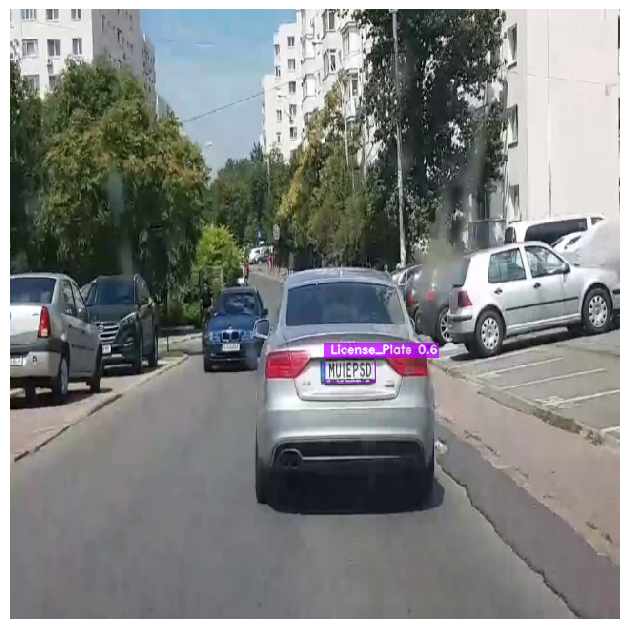

In [17]:
import cv2
import requests
import numpy as np
url = 'https://emerging-europe.com/wp-content/uploads/2018/07/maxresdefault-990x556-1.jpg'
img_array = np.asarray(bytearray(requests.get(url).content), dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (640, 640))  # must be multiple of 32

prediction = model.predict(img, conf=0.5)
prediction.show()

In [ ]:
export_result = model.export(
    output="../models/yolox_n_lp.onnx",
    input_image_shape=(640, 640),
    onnx_export_kwargs={"opset_version": 11}
)

print(export_result)

/usr/local/lib/python3.8/dist-packages/super_gradients/training/models/detection_models/yolo_base.py:270: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if self.grid[i].shape[2:4] != output.shape[2:4]:
/usr/local/lib/python3.8/dist-packages/onnx_graphsurgeon/importers/onnx_importer.py:87: DeprecationWarning: `mapping.TENSOR_TYPE_TO_NP_TYPE` is now deprecated and will be removed in a future release.To silence this warning, please use `helper.tensor_dtype_to_np_dtype` instead.
  return onnx.mapping.TENSOR_TYPE_TO_NP_TYPE[onnx_type]
/usr/local/lib/python3.8/dist-packages/torch/onnx/symbolic_opset9.py:2905: UserWarning: Exporting aten::index operator of advanced indexing in opset 11 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat,

Model exported successfully to ../models/yolox_n_lp.onnx
Model expects input image of shape [1, 3, 640, 640]
Input image dtype is torch.uint8
Exported model already contains preprocessing (normalization) step, so you don't need to do it manually.
Preprocessing steps to be applied to input image are:
Sequential(
  (0): CastTensorTo(dtype=torch.float32)
  (1): ChannelSelect(channels_indexes=tensor([2, 1, 0], device='cuda:0'))
)

Exported model contains postprocessing (NMS) step with the following parameters:
    num_pre_nms_predictions=1000
    max_predictions_per_image=1000
    nms_threshold=0.65
    confidence_threshold=0.5
    output_predictions_format=batch

Exported model is in ONNX format and can be used with ONNXRuntime
To run inference with ONNXRuntime, please use the following code snippet:

    import onnxruntime
    import numpy as np
    session = onnxruntime.InferenceSession("../models/yolox_n_lp.onnx", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    inputs 